In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn import datasets
iris = datasets.load_iris()

In [3]:
x=iris["data"][:,:2]
y=iris["target"]

In [4]:
from sklearn.linear_model import LogisticRegression
softmax_reg=LogisticRegression(multi_class="multinomial",C=10,random_state=1)
softmax_reg.fit(x,y)
softmax_reg.intercept_,softmax_reg.coef_

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


(array([ 13.81810643,  -0.51519673, -13.3029097 ]),
 array([[-5.10003926,  4.5761252 ],
        [ 1.65072691, -2.55845886],
        [ 3.44931235, -2.01766635]]))

In [5]:
softmax_reg.score(x,y)

0.8333333333333334

In [6]:
x_new=[[6.7,4.25],[4.9,3.3],[5.2,2.5]]

In [7]:
softmax_reg.predict(x_new)

array([2, 0, 1])

In [8]:
softmax_reg.predict_proba(x_new)

array([[8.89475199e-02, 1.58047310e-01, 7.53005171e-01],
       [9.90920309e-01, 8.16582501e-03, 9.13866077e-04],
       [4.51484756e-02, 8.49100249e-01, 1.05751275e-01]])

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf=SGDClassifier(loss='log_loss',penalty='l2',alpha=0.0001,random_state=1)
sgd_clf.fit(x,y)
sgd_clf.intercept_,sgd_clf.coef_

(array([  67.59518636,  124.33517776, -238.06632105]),
 array([[-84.60916926, 133.72318349],
        [  7.37256055, -71.29148328],
        [ 44.62371868, -21.55072196]]))

In [11]:
sgd_clf.score(x,y)

0.7266666666666667

In [12]:
x_new=[[6.7,4.25],[4.9,3.3],[5.2,2.5]]

In [13]:
sgd_clf.predict(x_new)

array([0, 0, 1])

In [14]:
sgd_clf.predict_proba(x_new)

array([[1.00000000e+00, 7.31465464e-57, 4.75034420e-14],
       [1.00000000e+00, 3.26786776e-33, 4.83519633e-40],
       [1.67788087e-10, 1.00000000e+00, 5.51862531e-20]])

In [15]:
x1,x2=np.meshgrid(np.linspace(4.2,8,1000).reshape(-1,1),np.linspace(1.8,4.5,1000).reshape(-1,1))
x_new=np.c_[x1.ravel(),x2.ravel()]
y_pred=softmax_reg.predict(x_new)

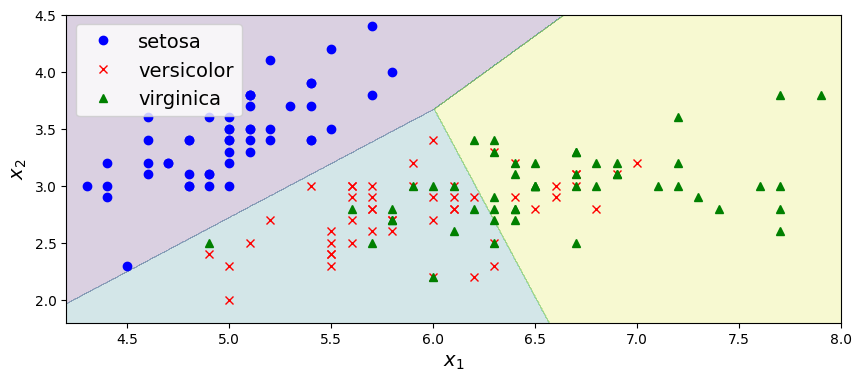

In [16]:
plt.figure(figsize=(10,4))
plt.plot(x[y==0,0],x[y==0,1],"bo",label="setosa")
plt.plot(x[y==1,0],x[y==1,1],"rx",label="versicolor")
plt.plot(x[y==2,0],x[y==2,1],"g^",label="virginica")

zz=y_pred.reshape(x1.shape)
plt.contourf(x1,x2,zz,alpha=0.2)

plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$",fontsize=14)
plt.legend(loc="upper left",fontsize=14)
plt.axis([4.2,8,1.8,4.5])
plt.show()